# Speech Commands - Intent Slot Filling (action, object, location)

Pipeline aggiornata rispetto alla versione precedente (classificazione di genere):

1. **Età** aggiunta ai metadati (`age_range`, dalle fasce originali del dataset: `22-40`, `41-65`, `65+`).
2. L'output per ogni campione è un **JSON** con i 3 slot dell'intento FSC: `{"object": ..., "action": ..., "location": ...}`.
3. **Train e dev** contengono solo speaker **uomini con età 22-40**.
4. **Test** contiene tutti gli altri speaker. Gli speaker di train/dev e quelli di test sono **disgiunti** (nessuna sovrapposizione in nessuna direzione).

Per ciascuno slot vengono allenati 2 classificatori (via `pyAudioAnalysis`): **SVM** e **GradientBoosting (GBC)**, poi confrontati su dev e test sia per accuracy-per-slot che per *exact match* del JSON completo.

In [16]:
import os
import csv
import json
import shutil
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import kagglehub

from pyAudioAnalysis import audioTrainTest as aT
from pyAudioAnalysis import MidTermFeatures as mtf

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
# np.Inf was removed in the NumPy 2.0 release. Use np.inf instead.
if not hasattr(np, "Inf"):
    np.Inf = np.inf
if not hasattr(np, "NaN"):
    np.NaN = np.nan

In [18]:
dataset_path = Path(kagglehub.dataset_download(
    "tommyngx/fluent-speech-corpus"
))
print("dataset_path:", dataset_path)


dataset_path: C:\Users\matte\.cache\kagglehub\datasets\tommyngx\fluent-speech-corpus\versions\1


In [19]:
def load_complete_map(dataset_path):
    """
    Carica i metadati del Fluent Speech Commands dataset, fondendo TUTTI
    gli split ufficiali (train/valid/test forniti da Kaggle) in un unico
    pool di campioni. Lo split finale (train/dev/test) con i vincoli
    richiesti (eta/genere/speaker disjoint) viene ricostruito a parte
    da `build_speaker_splits`, quindi qui non importa da quale csv
    ufficiale provenga ciascuna riga.

    Per ogni campione vengono raccolti:
        - rel_path:    percorso relativo del file .wav
        - speaker_id:  id del parlante
        - gender:      "M" o "F"
        - age_range:   fascia di eta originale (es. "22-40", "41-65", "65+")
        - action, object, location: i 3 slot semantici dell'intento (FSC)
    """
    csv_demographics = list(Path(dataset_path).rglob("speaker_demographics.csv"))[0]

    gender_map = {}
    age_map = {}
    with open(csv_demographics, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            sid = row["speakerId"].strip()
            g = row["gender"].strip().lower()
            age_range = row["ageRange"].strip()

            if g.startswith("f"):
                gender_map[sid] = "F"
            elif g.startswith("m"):
                gender_map[sid] = "M"

            age_map[sid] = age_range

    audio_metadata = []

    # Tutti i csv per-utterance tranne quello demografico: includono sia
    # i csv ufficiali di train, sia quelli di valid/test (qualunque sia il
    # loro nome, es. train_data.csv / valid_data.csv / test_data.csv).
    # Li fondiamo tutti: lo split definitivo lo facciamo noi dopo.
    csv_files = [p for p in Path(dataset_path).rglob("*.csv")
                 if "demographics" not in p.name]

    seen_rows = set()

    for csv_file in csv_files:
        with open(csv_file, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)

            for row in reader:
                sid = row.get("speakerId", "").strip()
                rel_path = row.get("path", "").strip()

                action = row.get("action", "unknown").strip().lower()
                obj = row.get("object", "unknown").strip().lower()
                location = row.get("location", "unknown").strip().lower()

                gender = gender_map.get(sid)
                age_range = age_map.get(sid)

                if not (gender and rel_path):
                    continue

                # Evita duplicati nel caso lo stesso file compaia in piu'
                # di un csv (non dovrebbe succedere con gli split ufficiali,
                # ma e' una protezione a basso costo dato che li fondiamo).
                dedup_key = (sid, rel_path)
                if dedup_key in seen_rows:
                    continue
                seen_rows.add(dedup_key)

                audio_metadata.append({
                    "rel_path": rel_path,
                    "speaker_id": sid,
                    "gender": gender,
                    "age_range": age_range,
                    "action": action,
                    "object": obj,
                    "location": location,
                })

    print(f"Loaded metadata: {len(audio_metadata)} samples")
    return audio_metadata


Loaded metadata: 30043 samples
--- 1. Analisi Globale ---


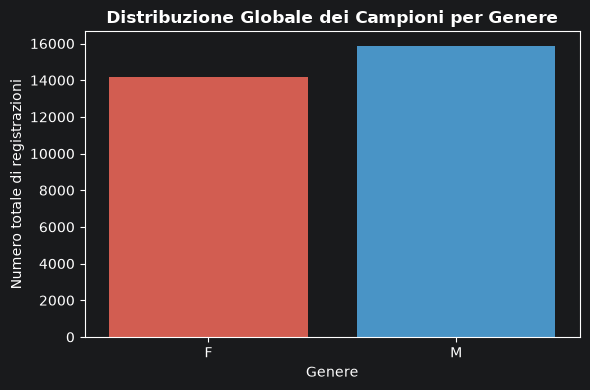

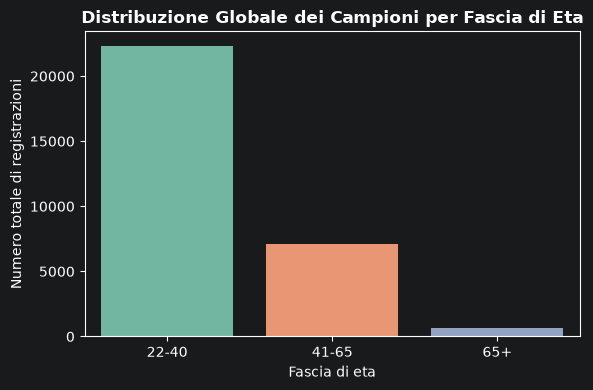

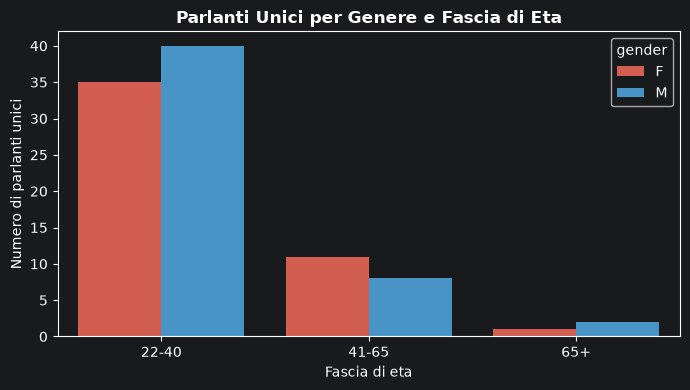

Speaker eleggibili per train/dev (uomini, eta 22-40): 40


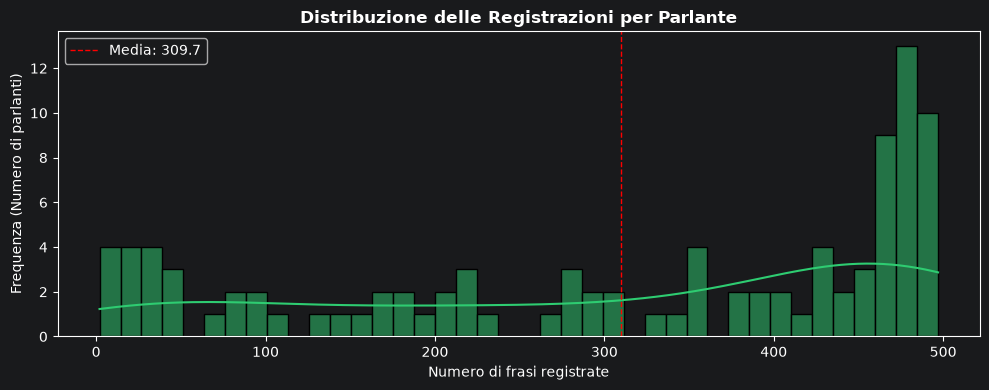


--- 2. Analisi Stratificata per Slot (action / object / location) ---


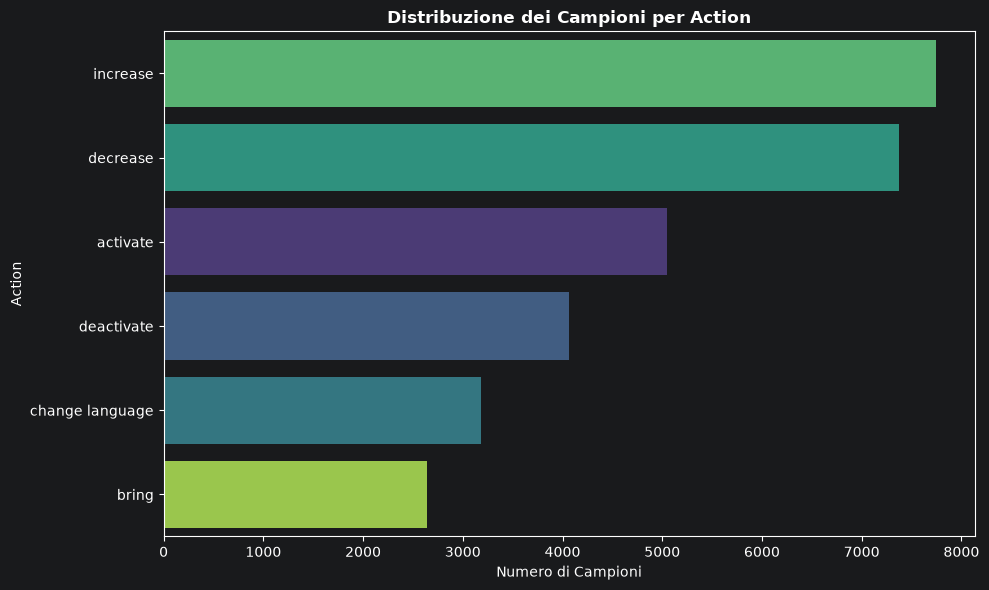

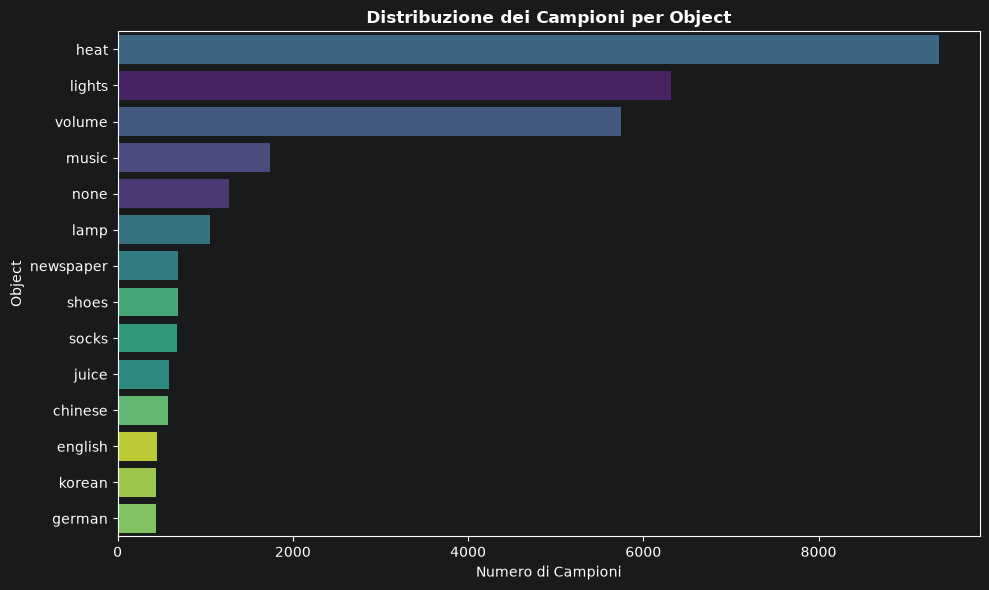

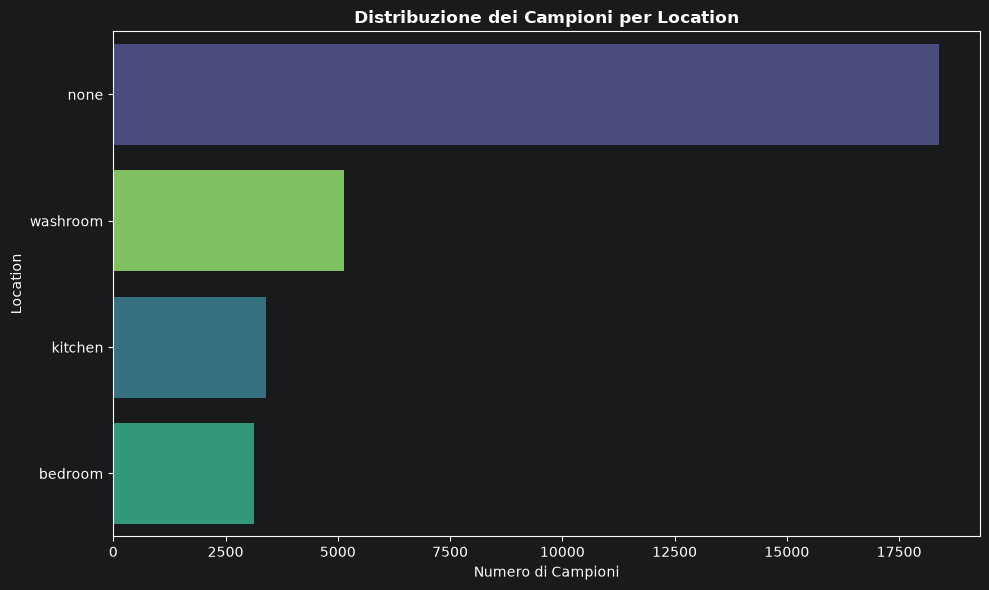

In [20]:
Path("./plots").mkdir(exist_ok=True)

# Conversione dei metadati in un DataFrame Pandas per facilitare l'analisi
df = pd.DataFrame(load_complete_map(dataset_path))

# ==============================================================================
# 1. ANALISI ESPLORATIVA GLOBALE (GENERE + ETA)
# ==============================================================================
print("--- 1. Analisi Globale ---")

# Grafico A: Sbilanciamento Globale per Genere
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='gender', palette={'M': '#3498db', 'F': '#e74c3c'}, legend=False)
plt.title("Distribuzione Globale dei Campioni per Genere", weight='bold')
plt.xlabel("Genere")
plt.ylabel("Numero totale di registrazioni")
plt.tight_layout()
plt.savefig("./plots/eda_1_gender_distribution.png", dpi=150)
plt.show()

# Grafico A2: Distribuzione per fascia di eta (age_range)
plt.figure(figsize=(6, 4))
order_age = df['age_range'].value_counts().index
sns.countplot(data=df, x='age_range', order=order_age, hue='age_range', palette='Set2', legend=False)
plt.title("Distribuzione Globale dei Campioni per Fascia di Eta", weight='bold')
plt.xlabel("Fascia di eta")
plt.ylabel("Numero totale di registrazioni")
plt.tight_layout()
plt.savefig("./plots/eda_1b_age_distribution.png", dpi=150)
plt.show()

# Grafico A3: incrocio genere x eta a livello di speaker unici, utile per
# capire quanti speaker soddisfano il vincolo "uomini, eta 22-40" richiesto
# per train/dev
speakers_df = df.drop_duplicates(subset='speaker_id')[['speaker_id', 'gender', 'age_range']]
plt.figure(figsize=(7, 4))
sns.countplot(data=speakers_df, x='age_range', order=order_age, hue='gender',
              palette={'M': '#3498db', 'F': '#e74c3c'})
plt.title("Parlanti Unici per Genere e Fascia di Eta", weight='bold')
plt.xlabel("Fascia di eta")
plt.ylabel("Numero di parlanti unici")
plt.tight_layout()
plt.savefig("./plots/eda_1c_speakers_gender_age.png", dpi=150)
plt.show()

n_eligible = speakers_df[(speakers_df['gender'] == 'M') & (speakers_df['age_range'] == '22-40')]['speaker_id'].nunique()
print(f"Speaker eleggibili per train/dev (uomini, eta 22-40): {n_eligible}")

# Grafico B: Sbilanciamento delle registrazioni per singolo parlante
speaker_counts = df['speaker_id'].value_counts()

plt.figure(figsize=(10, 4))
sns.histplot(speaker_counts, bins=40, kde=True, color='#2ecc71')
plt.title("Distribuzione delle Registrazioni per Parlante", weight='bold')
plt.xlabel("Numero di frasi registrate")
plt.ylabel("Frequenza (Numero di parlanti)")
plt.axvline(speaker_counts.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Media: {speaker_counts.mean():.1f}')
plt.legend()
plt.tight_layout()
plt.savefig("./plots/eda_2_speaker_imbalance.png", dpi=150)
plt.show()

# ==============================================================================
# 2. ANALISI ESPLORATIVA DEI 3 SLOT DELL'INTENTO (action, object, location)
# ==============================================================================
print("\n--- 2. Analisi Stratificata per Slot (action / object / location) ---")

for slot in ["action", "object", "location"]:
    plt.figure(figsize=(10, 6))
    order = df[slot].value_counts().index
    sns.countplot(data=df, y=slot, order=order, hue=slot, palette='viridis', legend=False)
    plt.title(f"Distribuzione dei Campioni per {slot.capitalize()}", weight='bold')
    plt.xlabel("Numero di Campioni")
    plt.ylabel(slot.capitalize())
    plt.tight_layout()
    plt.savefig(f"./plots/eda_3_{slot}_distribution.png", dpi=150)
    plt.show()


In [21]:
def resolve_audio_path(dataset_path, rel_path):
    dataset_path = Path(dataset_path)

    # Extract the nested top-level directory name dynamically if needed,
    # or explicitly add the known folder to the search tree
    nested_dir = dataset_path / "fluent_speech_commands_dataset"

    candidates = [
        dataset_path / rel_path,
        nested_dir / rel_path,  # <-- Added this critical candidate
        dataset_path / Path(rel_path).name,
        nested_dir / Path(rel_path).name,
        dataset_path / "data" / rel_path,
        dataset_path / "wav" / rel_path,
        dataset_path / "audio" / rel_path,
        Path(rel_path)
    ]

    for c in candidates:
        if c.exists():
            return c

    return None

In [22]:
audio = load_complete_map(dataset_path)
print(audio[0]["rel_path"])
print({k: audio[0][k] for k in ("speaker_id", "gender", "age_range", "action", "object", "location")})


Loaded metadata: 30043 samples
wavs/speakers/4BrX8aDqK2cLZRYl/cbdf5700-452c-11e9-b1e4-e5985dca719e.wav
{'speaker_id': '4BrX8aDqK2cLZRYl', 'gender': 'F', 'age_range': '22-40', 'action': 'activate', 'object': 'lights', 'location': 'none'}


In [23]:
SLOTS = ["action", "object", "location"]


def build_speaker_splits(audio_metadata, dev_fraction=0.2, random_state=42):
    """
    Costruisce gli insiemi di speaker_id per train/dev/test secondo i
    vincoli richiesti:

      - train e dev contengono SOLO uomini con fascia di eta "22-40"
        (split per speaker, cosi' lo stesso parlante non finisce sia in
        train che in dev)
      - test contiene tutti gli altri speaker (qualsiasi genere/eta) che
        NON soddisfano il vincolo train/dev
      - i parlanti di train/dev non compaiono MAI in test e viceversa
        (garantito per costruzione, dato che partizioniamo gli speaker
        e non i singoli file)

    Ritorna 3 set di speaker_id: (train_speakers, dev_speakers, test_speakers)
    """
    speakers = {}
    for m in audio_metadata:
        speakers[m["speaker_id"]] = (m["gender"], m["age_range"])

    eligible = sorted([sid for sid, (g, a) in speakers.items()
                        if g == "M" and a == "22-40"])
    rest = sorted([sid for sid in speakers if sid not in eligible])

    if len(eligible) == 0:
        raise ValueError(
            "Nessuno speaker soddisfa il vincolo richiesto per train/dev "
            "(gender == 'M' e age_range == '22-40'). Verifica i valori "
            "reali della colonna ageRange nel dataset."
        )

    rng = random.Random(random_state)
    eligible_shuffled = eligible[:]
    rng.shuffle(eligible_shuffled)

    n_dev = max(1, int(round(len(eligible_shuffled) * dev_fraction)))
    dev_speakers = set(eligible_shuffled[:n_dev])
    train_speakers = set(eligible_shuffled[n_dev:])
    test_speakers = set(rest)

    print(f"Speaker totali: {len(speakers)}")
    print(f"Speaker eleggibili (M, 22-40): {len(eligible)}")
    print(f"  -> train: {len(train_speakers)} speaker")
    print(f"  -> dev:   {len(dev_speakers)} speaker")
    print(f"Speaker in test (tutti gli altri): {len(test_speakers)} speaker")

    # Garanzia esplicita di disgiunzione (richiesta 4): nessuno speaker di
    # train/dev deve comparire in test e viceversa.
    assert train_speakers.isdisjoint(test_speakers)
    assert dev_speakers.isdisjoint(test_speakers)
    assert train_speakers.isdisjoint(dev_speakers)

    return train_speakers, dev_speakers, test_speakers


def build_split_workspace(audio_metadata, dataset_path, speaker_ids, workspace_dir):
    """
    Copia i file audio degli speaker indicati dentro `workspace_dir`,
    organizzati in sotto-cartelle per classe per OGNUNO dei 3 slot
    (action / object / location), cosi' che pyAudioAnalysis possa
    allenare un classificatore per slot (1 cartella = 1 classe).

    workspace_dir/
        action/<classe_action>/*.wav
        object/<classe_object>/*.wav
        location/<classe_location>/*.wav

    Lo stesso file fisico viene copiato (come hardlink se possibile,
    altrimenti copiato) sotto le 3 viste, perche' pyAudioAnalysis
    organizza i dati per cartella-di-classe e non supporta multi-label
    nativamente. Ritorna anche la lista di metadati effettivamente usati,
    utile per la valutazione successiva.
    """
    workspace_dir = Path(workspace_dir)
    if workspace_dir.exists():
        shutil.rmtree(workspace_dir)

    for slot in SLOTS:
        (workspace_dir / slot).mkdir(parents=True, exist_ok=True)

    used_metadata = []

    for m in audio_metadata:
        if m["speaker_id"] not in speaker_ids:
            continue

        src = resolve_audio_path(dataset_path, m["rel_path"])
        if src is None:
            continue

        # Nome file univoco anche se piu' speaker avessero file omonimi
        dest_name = f"{m['speaker_id']}__{src.name}"

        for slot in SLOTS:
            class_value = m[slot]
            class_dir = workspace_dir / slot / class_value
            class_dir.mkdir(parents=True, exist_ok=True)
            dest = class_dir / dest_name
            if not dest.exists():
                try:
                    os.link(src, dest)
                except OSError:
                    shutil.copy(src, dest)

        # Percorso fisico di riferimento (qualsiasi slot va bene: il file
        # e' identico nelle 3 viste, cambia solo la cartella di classe)
        workspace_path = workspace_dir / "object" / m["object"] / dest_name
        used_metadata.append({**m, "_dest_name": dest_name, "_workspace_path": str(workspace_path)})

    return used_metadata


def train_slot_models(workspace_dir, model_type, model_prefix):
    """
    Allena un classificatore (model_type: "svm_rbf" oppure "gradientboosting")
    per ciascuno dei 3 slot (action/object/location), usando le sotto-cartelle
    per classe create da `build_split_workspace`.

    Ritorna un dict {slot: model_name} con i nomi dei modelli salvati.
    """
    workspace_dir = Path(workspace_dir)
    model_names = {}

    for slot in SLOTS:
        slot_dir = workspace_dir / slot
        class_folders = sorted(str(p) for p in slot_dir.iterdir() if p.is_dir())

        if len(class_folders) < 2:
            print(f"Skip training per slot '{slot}': servono almeno 2 classi, trovate {len(class_folders)}.")
            continue

        model_name = f"{model_prefix}_{slot}"
        print(f"\nTraining {model_type} per slot '{slot}' ({len(class_folders)} classi)...")

        aT.extract_features_and_train(
            class_folders,
            1.0, 1.0,   # mt win/step
            0.05, 0.025,   # st win/step
            model_type,
            model_name,
            False
        )

        model_names[slot] = model_name
        print(f"Training completato: {model_name}")

    return model_names


In [24]:
def predict_intent_json(wav_path, model_names, model_type):
    """
    Predice i 3 slot (action, object, location) per un singolo file audio
    usando i modelli (uno per slot) indicati in `model_names`, e li
    combina in un unico oggetto json:

        {"object": ..., "action": ..., "location": ...}

    Ritorna (intent_json, raw_pred_dict) dove raw_pred_dict contiene la
    predizione "grezza" per ogni slot (utile per calcolare le accuracy
    per singolo slot).
    """
    raw_pred = {}

    for slot, model_name in model_names.items():
        try:
            class_id, class_names, _ = aT.file_classification(str(wav_path), model_name, model_type)
            pred_label = class_names[int(class_id)]
        except Exception as e:
            pred_label = None
        raw_pred[slot] = pred_label

    intent_json = {
        "object": raw_pred.get("object"),
        "action": raw_pred.get("action"),
        "location": raw_pred.get("location"),
    }

    return intent_json, raw_pred


def evaluate_split(used_metadata, model_names, model_type):
    """
    Valuta un insieme di campioni (es. dev o test) con i modelli allenati
    per i 3 slot. Per ogni file produce il json dell'intento predetto e lo
    confronta con la verita' di terreno.

    Ritorna:
        - results: lista di dict con true/pred per ogni file (incluso il
          json completo predetto)
        - metrics: dict con accuracy per slot + exact match accuracy
          (il json predetto deve coincidere ESATTAMENTE su tutti e 3 i
          campi con quello reale)
    """
    results = []
    y_true_slot = {slot: [] for slot in SLOTS}
    y_pred_slot = {slot: [] for slot in SLOTS}
    exact_matches = 0

    for m in used_metadata:
        wav_path = Path(m["_workspace_path"])

        pred_json, raw_pred = predict_intent_json(wav_path, model_names, model_type)

        true_json = {
            "object": m["object"],
            "action": m["action"],
            "location": m["location"],
        }

        for slot in SLOTS:
            y_true_slot[slot].append(m[slot])
            y_pred_slot[slot].append(raw_pred.get(slot))

        is_exact_match = (pred_json == true_json)
        exact_matches += int(is_exact_match)

        results.append({
            "rel_path": m["rel_path"],
            "speaker_id": m["speaker_id"],
            "true_intent": true_json,
            "pred_intent": pred_json,
            "exact_match": is_exact_match,
        })

    n = len(used_metadata)
    metrics = {
        "n_samples": n,
        "exact_match_accuracy": exact_matches / n if n else 0.0,
        "slot_accuracy": {},
    }

    for slot in SLOTS:
        yt = y_true_slot[slot]
        yp = y_pred_slot[slot]
        correct = sum(1 for t, p in zip(yt, yp) if t == p)
        metrics["slot_accuracy"][slot] = correct / n if n else 0.0

    return results, metrics


In [25]:
def plot_slot_confusion_matrices(results, slot, title_prefix):
    """
    Disegna la confusion matrix per un singolo slot (action/object/location),
    usando le etichette osservate in `results` (true_intent / pred_intent).
    """
    plots_dir = Path("./plots")
    plots_dir.mkdir(exist_ok=True)

    y_true = [r["true_intent"][slot] for r in results]
    y_pred = [r["pred_intent"][slot] for r in results]

    labels = sorted(set(y_true) | {p for p in y_pred if p is not None})
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(max(5, len(labels) * 0.6), max(4, len(labels) * 0.6)))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"{title_prefix} - {slot}", weight="bold")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=8)

    plt.tight_layout()
    clean_name = f"{title_prefix}_{slot}".lower().replace(" ", "_")
    plot_path = plots_dir / f"confusion_matrix_{clean_name}.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Grafico salvato in: {plot_path}")


In [26]:
def print_sample_predictions(results, n=5, title="Esempi di predizione"):
    """
    Stampa alcuni esempi di output: per ciascun file mostra il json
    dell'intento reale e quello predetto, nel formato richiesto
    {"object": ..., "action": ..., "location": ...}.
    """
    print(f"\n--- {title} (primi {n} esempi) ---")
    for r in results[:n]:
        print(f"file: {r['rel_path']}")
        print(f"  true: {json.dumps(r['true_intent'])}")
        print(f"  pred: {json.dumps(r['pred_intent'])}  (exact_match={r['exact_match']})")


In [27]:
def plot_summary(svm_metrics, gbc_metrics, split_name):
    """
    Confronta SVM vs GradientBoosting su un determinato split (dev/test):
    accuracy per slot + exact match accuracy, in un unico grafico a barre.
    """
    plots_dir = Path("./plots")
    plots_dir.mkdir(exist_ok=True)

    labels = SLOTS + ["exact_match"]
    svm_vals = [svm_metrics["slot_accuracy"][s] for s in SLOTS] + [svm_metrics["exact_match_accuracy"]]
    gbc_vals = [gbc_metrics["slot_accuracy"][s] for s in SLOTS] + [gbc_metrics["exact_match_accuracy"]]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 5))
    bars_svm = plt.bar(x - width/2, svm_vals, width, label='SVM', color='#34495e')
    bars_gbc = plt.bar(x + width/2, gbc_vals, width, label='GradientBoosting', color='#1abc9c')

    plt.ylabel('Accuracy')
    plt.title(f'SVM vs GradientBoosting - {split_name}', weight='bold')
    plt.xticks(x, labels)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()

    for bars in [bars_svm, bars_gbc]:
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02,
                     f"{yval:.2%}", ha='center', va='bottom', weight='bold', fontsize=9)

    plt.tight_layout()
    summary_path = plots_dir / f"accuracy_comparison_{split_name.lower()}.png"
    plt.savefig(summary_path, dpi=150)
    plt.show()
    print(f"Grafico riassuntivo salvato in: {summary_path}")


In [28]:
# Diagnostic: find out where the .wav files actually live on disk,
# since resolve_audio_path's guessed candidates may not match the
# real kagglehub download layout. Run this once and inspect the output
# before re-running the training/eval loop below.

print("Top-level contents of dataset_path:")
for p in sorted(dataset_path.iterdir()):
    print(" ", p.name, "[dir]" if p.is_dir() else "[file]")

print()
print("First 5 .wav files found anywhere under dataset_path:")
count = 0
for wav in dataset_path.rglob("*.wav"):
    print(" ", wav.relative_to(dataset_path))
    count += 1
    if count >= 5:
        break

if count == 0:
    print("  No .wav files found at all under dataset_path!")

Top-level contents of dataset_path:
  fluent_speech_commands_dataset [dir]

First 5 .wav files found anywhere under dataset_path:
  fluent_speech_commands_dataset\wavs\speakers\2BqVo8kVB2Skwgyb\029f6450-447a-11e9-a9a5-5dbec3b8816a.wav
  fluent_speech_commands_dataset\wavs\speakers\2BqVo8kVB2Skwgyb\03592c80-447c-11e9-a9a5-5dbec3b8816a.wav
  fluent_speech_commands_dataset\wavs\speakers\2BqVo8kVB2Skwgyb\063aa8f0-4479-11e9-a9a5-5dbec3b8816a.wav
  fluent_speech_commands_dataset\wavs\speakers\2BqVo8kVB2Skwgyb\07858300-447a-11e9-a9a5-5dbec3b8816a.wav
  fluent_speech_commands_dataset\wavs\speakers\2BqVo8kVB2Skwgyb\0887f780-447d-11e9-a9a5-5dbec3b8816a.wav


In [ ]:
audio_metadata = load_complete_map(dataset_path)

# --- 1. Costruzione split a livello di SPEAKER (richiesta 3 e 4) ---
# train/dev: solo uomini, eta 22-40
# test:      tutti gli altri speaker
# nessuno speaker e' condiviso tra (train+dev) e test
train_speakers, dev_speakers, test_speakers = build_speaker_splits(audio_metadata)

# --- 2. Costruzione dei workspace fisici (cartelle per classe per slot) ---
train_meta = build_split_workspace(audio_metadata, dataset_path, train_speakers, "./workspace_train")
dev_meta   = build_split_workspace(audio_metadata, dataset_path, dev_speakers,   "./workspace_dev")
test_meta  = build_split_workspace(audio_metadata, dataset_path, test_speakers,  "./workspace_test")

print(f"Campioni train: {len(train_meta)}")
print(f"Campioni dev:   {len(dev_meta)}")
print(f"Campioni test:  {len(test_meta)}")

# Verifica esplicita di non sovrapposizione tra gli speaker effettivamente
# usati nei 3 split (richiesta 4)
sids_train = {m["speaker_id"] for m in train_meta}
sids_dev   = {m["speaker_id"] for m in dev_meta}
sids_test  = {m["speaker_id"] for m in test_meta}
assert sids_train.isdisjoint(sids_test)
assert sids_dev.isdisjoint(sids_test)
print("OK: nessuno speaker di train/dev e' presente in test (e viceversa).")

# --- 3. Training: un modello SVM e un modello GradientBoosting (GBC) per
#        ciascuno dei 3 slot (action/object/location), allenati SOLO su train ---
svm_models = train_slot_models("./workspace_train", "svm_rbf", "model_intent_svm")
gbc_models = train_slot_models("./workspace_train", "gradientboosting", "model_intent_gbc")

# --- 4. Valutazione su DEV e su TEST, per entrambi i modelli ---
all_metrics = {}

for split_name, split_meta in [("Dev", dev_meta), ("Test", test_meta)]:
    print(f"\n=== Valutazione su {split_name} ===")

    svm_results, svm_metrics = evaluate_split(split_meta, svm_models, "svm_rbf")
    gbc_results, gbc_metrics = evaluate_split(split_meta, gbc_models, "gradientboosting")

    print(f"[SVM] {split_name} - exact match accuracy: {svm_metrics['exact_match_accuracy']:.2%}")
    print(f"[SVM] {split_name} - accuracy per slot: {svm_metrics['slot_accuracy']}")
    print(f"[GBC] {split_name} - exact match accuracy: {gbc_metrics['exact_match_accuracy']:.2%}")
    print(f"[GBC] {split_name} - accuracy per slot: {gbc_metrics['slot_accuracy']}")

    print_sample_predictions(svm_results, n=5, title=f"SVM - {split_name}")
    print_sample_predictions(gbc_results, n=5, title=f"GBC - {split_name}")

    for slot in SLOTS:
        plot_slot_confusion_matrices(svm_results, slot, f"SVM {split_name}")
        plot_slot_confusion_matrices(gbc_results, slot, f"GBC {split_name}")

    plot_summary(svm_metrics, gbc_metrics, split_name)

    all_metrics[split_name] = {"svm": svm_metrics, "gbc": gbc_metrics}

print("\nRiepilogo finale metriche:")
print(json.dumps(all_metrics, indent=2))


Loaded metadata: 30043 samples
Speaker totali: 97
Speaker eleggibili (M, 22-40): 40
  -> train: 32 speaker
  -> dev:   8 speaker
Speaker in test (tutti gli altri): 57 speaker
Campioni train: 10084
Campioni dev:   2072
Campioni test:  17887
OK: nessuno speaker di train/dev e' presente in test (e viceversa).

Training svm_rbf per slot 'action' (6 classi)...
Analyzing file 1 of 1621: workspace_train\action\activate\4aGjX3AG5xcxeL7a__15be01a0-451e-11e9-a843-8db76f4b5e29.wav
Analyzing file 2 of 1621: workspace_train\action\activate\5BEzPgPKe8taG9OB__0064e980-457e-11e9-9600-8f19ade2128c.wav
Analyzing file 3 of 1621: workspace_train\action\activate\5BEzPgPKe8taG9OB__0283aad0-457e-11e9-9600-8f19ade2128c.wav
Analyzing file 4 of 1621: workspace_train\action\activate\5BEzPgPKe8taG9OB__04961010-457e-11e9-9600-8f19ade2128c.wav
Analyzing file 5 of 1621: workspace_train\action\activate\5BEzPgPKe8taG9OB__06a1e5a0-457e-11e9-9600-8f19ade2128c.wav
Analyzing file 6 of 1621: workspace_train\action\activate

C:\Users\matte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Param = 0.00100 - classifier Evaluation Experiment 2 of 5


C:\Users\matte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Param = 0.00100 - classifier Evaluation Experiment 3 of 5


...

C:\Users\matte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Param = 20.00000 - classifier Evaluation Experiment 4 of 5


C:\Users\matte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Param = 20.00000 - classifier Evaluation Experiment 5 of 5


C:\Users\matte\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
